# IT25100083 – Linear Support Vector Machine

**Student:** Unawatuna H. M. I. D.  
**IT number:** IT25100083  
**Project:** Emotion-Aware Movie Recommendation System  
**Primary preprocessing responsibility:** Encoding categorical variables  
**Assigned model:** Linear Support Vector Machine  

This notebook independently demonstrates missing-data handling, categorical encoding, outlier treatment, scaling, feature engineering, feature selection, dimensionality reduction, EDA, leakage-safe model tuning, cross-validation, and final evaluation.

## 1. Reproducibility and imports

Random state 42 is used throughout. All learned preprocessing steps used for modelling are fitted only on training folds through a scikit-learn pipeline.

In [1]:
from pathlib import Path
import json
import warnings

import cloudpickle
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.impute import SimpleImputer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data").exists():
    raise FileNotFoundError("Could not locate the repository root containing the data directory.")
DATA_PATH = PROJECT_ROOT / "data/processed/modelling_dataset_7class.csv"
MEMBER_DIR = PROJECT_ROOT / "IT25100083"
EDA_DIR = MEMBER_DIR / "results/eda_visualizations"
MODEL_FIG_DIR = MEMBER_DIR / "results/model_visualizations"
OUTPUT_DIR = MEMBER_DIR / "results/outputs"
LOG_DIR = MEMBER_DIR / "results/logs"
for directory in [EDA_DIR, MODEL_FIG_DIR, OUTPUT_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Random state:", RANDOM_STATE)
print("Dataset path:", DATA_PATH)

Random state: 42
Dataset path: /Users/lakshithadilshan/Documents/movie-emotion-recommendation-system/data/processed/modelling_dataset_7class.csv


## 2. Load and understand the assigned dataset

The modelling unit is one unique movie description. The target is one of seven emotions. The `surprise` class remains in the full EDA dataset but is excluded here because it has only three independent descriptions, which is insufficient for reliable stratified validation.

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Duplicate descriptions:", int(df["Description"].duplicated().sum()))
display(df.head(3))
display(df.dtypes.to_frame("dtype"))

Shape: (2057, 20)
Duplicate descriptions: 0


,Description,emotion,movie_name,all_movie_names,movie_name_count,genres,mean_rating,median_rating,minimum_rating,maximum_rating,review_count,unique_review_count,genre_list,genre_count,genres_text,description_word_count,description_character_count,rating_range,log_review_count,log_unique_review_count
0,"A pretty, popular teenager can't go out on a d...",anger,10 Things I Hate About You,10 Things I Hate About You,1,"['Comedy', 'Romance', 'Drama']",6.428571,7.0,2.0,10.0,14,14,"['Comedy', 'Romance', 'Drama']",3,comedy romance drama,16,91,8.0,2.708050,2.708050
1,"A fast paced, womanizing nightclub promoter ge...",anger,A Thin Line Between Love and Hate,A Thin Line Between Love and Hate,1,"['Comedy', 'Thriller', 'Crime', 'Romance']",4.000000,4.0,4.0,4.0,1,1,"['Comedy', 'Thriller', 'Crime', 'Romance']",4,comedy thriller crime romance,28,169,0.0,0.693147,0.693147
2,"A cynical, immature young man is taught how to...",anger,About a Boy,About a Boy,1,"['Drama', 'Comedy', 'Romance']",6.352941,7.0,2.0,10.0,17,17,"['Drama', 'Comedy', 'Romance']",3,drama comedy romance,17,83,8.0,2.890372,2.890372


,dtype
Description,str
emotion,str
movie_name,str
all_movie_names,str
movie_name_count,int64
genres,str
mean_rating,float64
median_rating,float64
minimum_rating,float64
maximum_rating,float64


## 3. Missing-data handling

Missing values can cause vectorizers, encoders, scalers, and models to fail or silently lose records. The audit covers literal nulls, empty strings, and unavailable genre lists. Empty genre information is represented by the explicit category `unknown_genre`, preserving the observation instead of deleting it.

For leakage prevention, the modelling pipeline also contains `SimpleImputer`: most-frequent imputation for categorical inputs and median imputation for numerical inputs. These statistics are learned from training folds only.

In [3]:
blank_counts = {}
for column in df.select_dtypes(include=["object", "string"]).columns:
    blank_counts[column] = int(df[column].astype("string").str.strip().eq("").sum())

missing_audit = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "blank_count": pd.Series(blank_counts),
}).fillna(0).astype(int)

print("Total literal missing values:", int(df.isna().sum().sum()))
print("Total blank strings:", int(missing_audit["blank_count"].sum()))
print("Unknown-genre rows:", int(df["genres_text"].eq("unknown_genre").sum()))
display(missing_audit)

# Independent handling demonstration
demo_missing = df[["mean_rating", "genres_text"]].copy()
demo_missing.loc[demo_missing.index[0], "mean_rating"] = np.nan
demo_missing.loc[demo_missing.index[1], "genres_text"] = np.nan

numeric_imputer_demo = SimpleImputer(strategy="median")
category_imputer_demo = SimpleImputer(strategy="most_frequent")
demo_missing[["mean_rating"]] = numeric_imputer_demo.fit_transform(demo_missing[["mean_rating"]])
demo_missing["genres_text"] = category_imputer_demo.fit_transform(demo_missing[["genres_text"]]).ravel()
print("Demonstration missing values after imputation:", int(demo_missing.isna().sum().sum()))

Total literal missing values: 0
Total blank strings: 0
Unknown-genre rows: 35


,missing_count,blank_count
Description,0,0
all_movie_names,0,0
description_character_count,0,0
description_word_count,0,0
emotion,0,0
genre_count,0,0
genre_list,0,0
genres,0,0
genres_text,0,0
log_review_count,0,0


Demonstration missing values after imputation: 0


## 4. Exploratory data analysis

All figures are saved in the student's own results folder. Each visualization is followed by an interpretation and its influence on modelling.

### EDA 1 — Description word-count histogram

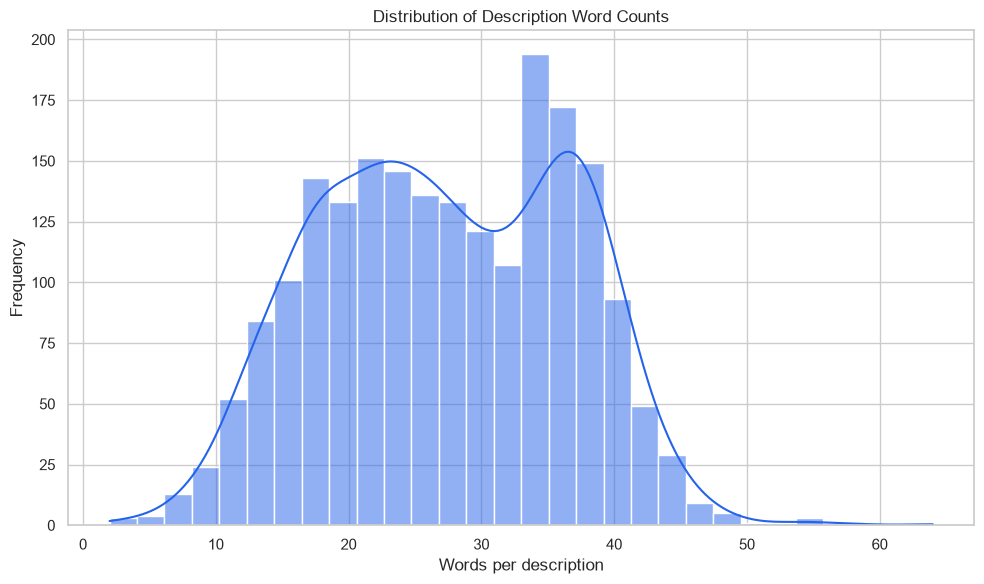

count    2057.000000
mean       27.317939
std         9.348216
min         2.000000
25%        20.000000
50%        27.000000
75%        35.000000
max        64.000000
Name: description_word_count, dtype: float64


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df["description_word_count"], bins=30, kde=True, color="#2563eb", ax=ax)
ax.set_title("Distribution of Description Word Counts")
ax.set_xlabel("Words per description")
ax.set_ylabel("Frequency")
fig.tight_layout()
fig.savefig(EDA_DIR / "01_description_word_count_histogram.png", dpi=300, bbox_inches="tight")
plt.show()
print(df["description_word_count"].describe())

**Interpretation:** Description lengths are right-skewed, with a small number of unusually long summaries. This supports IQR-based outlier treatment and scaling of engineered length features.

### EDA 2 — Description word-count boxplot

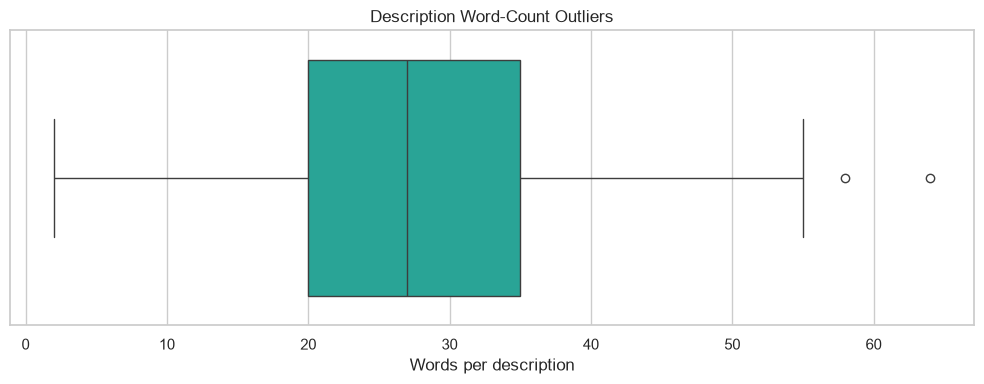

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x=df["description_word_count"], color="#14b8a6", ax=ax)
ax.set_title("Description Word-Count Outliers")
ax.set_xlabel("Words per description")
fig.tight_layout()
fig.savefig(EDA_DIR / "02_description_word_count_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation:** Observations beyond the upper whisker are potential length outliers. They are clipped rather than deleted because long descriptions remain legitimate movies and deletion could worsen class imbalance.

### EDA 3 — Description length by emotion

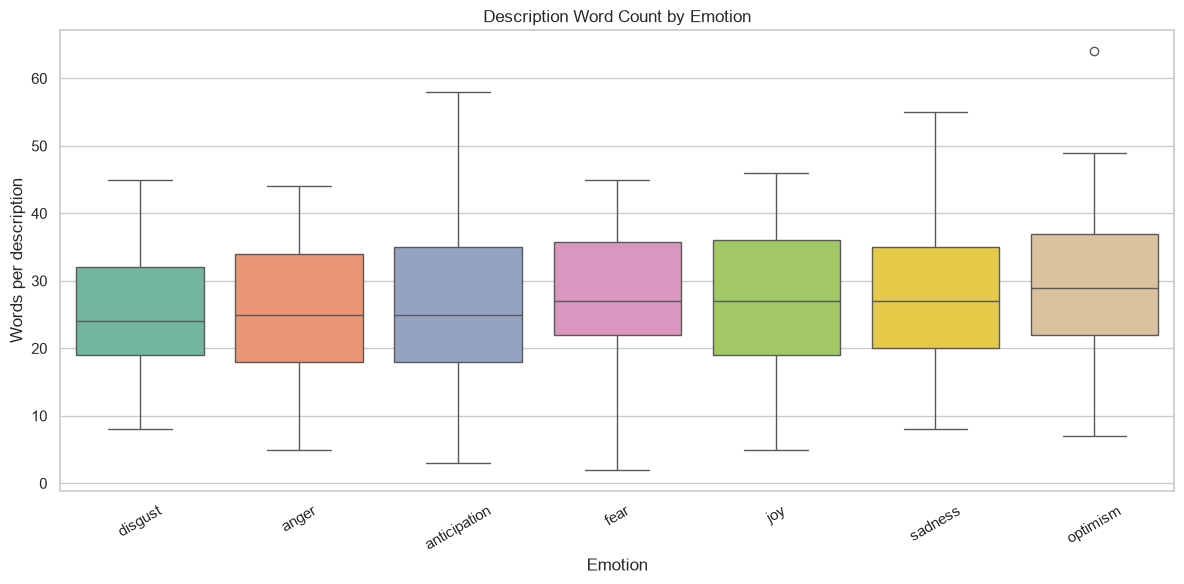

In [6]:
order = df.groupby("emotion")["description_word_count"].median().sort_values().index
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x="emotion", y="description_word_count", order=order, palette="Set2", ax=ax)
ax.set_title("Description Word Count by Emotion")
ax.set_xlabel("Emotion")
ax.set_ylabel("Words per description")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(EDA_DIR / "03_description_length_by_emotion.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation:** The emotion groups overlap strongly in description length. Length is useful as a supporting engineered feature but cannot replace semantic TF-IDF features.

### EDA 4 — Description word count versus mean rating

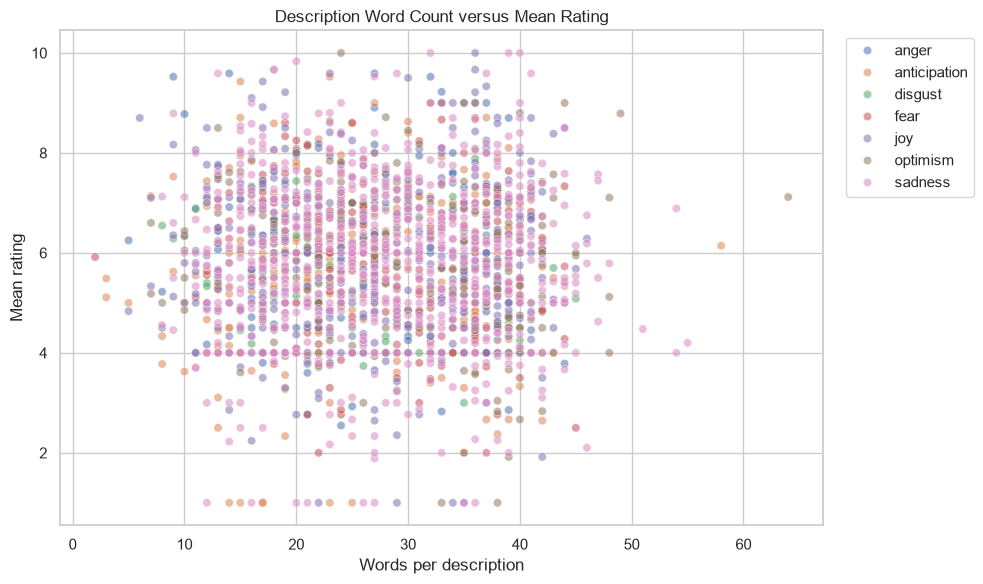

Pearson correlation: -0.0263


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x="description_word_count", y="mean_rating", hue="emotion", alpha=0.55, ax=ax)
ax.set_title("Description Word Count versus Mean Rating")
ax.set_xlabel("Words per description")
ax.set_ylabel("Mean rating")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(EDA_DIR / "04_word_count_vs_mean_rating.png", dpi=300, bbox_inches="tight")
plt.show()
print("Pearson correlation:", round(df["description_word_count"].corr(df["mean_rating"]), 4))

**Interpretation:** The scatter shows weak separation and substantial overlap, so neither rating nor length alone explains emotion. Combining text, encoded genre, and scaled numeric features is justified.

## 5. Feature engineering

The notebook uses description text, genre category, rating summaries, description lengths, genre count, rating range, and log-transformed review-popularity measures. These features represent semantic content, categorical context, quality, complexity, and popularity.

In [8]:
numeric_features = [
    "mean_rating",
    "median_rating",
    "genre_count",
    "description_word_count",
    "description_character_count",
    "rating_range",
    "log_review_count",
    "log_unique_review_count",
]
categorical_features = ["genres_text"]
text_feature = "Description"
target = "emotion"

model_columns = [text_feature] + categorical_features + numeric_features
X = df[model_columns].copy()
y = df[target].copy()

feature_summary = df[numeric_features].describe().T
display(feature_summary)
print("Input columns:", model_columns)

,count,mean,std,min,25%,50%,75%,max
mean_rating,2057.0,5.821238,1.525737,1.000000,4.846154,5.857143,6.888889,10.000000
median_rating,2057.0,5.940933,2.028622,1.000000,4.500000,6.000000,7.500000,10.000000
genre_count,2057.0,2.472533,1.132449,0.000000,2.000000,2.000000,3.000000,7.000000
description_word_count,2057.0,27.317939,9.348216,2.000000,20.000000,27.000000,35.000000,64.000000
description_character_count,2057.0,158.800681,54.026566,10.000000,116.000000,156.000000,213.000000,354.000000
rating_range,2057.0,5.683520,2.792166,0.000000,4.000000,7.000000,8.000000,9.000000
log_review_count,2057.0,2.682319,0.895590,0.693147,2.197225,2.772589,3.135494,7.686621
log_unique_review_count,2057.0,2.366288,0.728748,0.693147,1.945910,2.564949,2.944439,6.973543


Input columns: ['Description', 'genres_text', 'mean_rating', 'median_rating', 'genre_count', 'description_word_count', 'description_character_count', 'rating_range', 'log_review_count', 'log_unique_review_count']


## 6. Outlier detection and treatment

The IQR rule flags observations below $Q_1-1.5(IQR)$ or above $Q_3+1.5(IQR)$. Deleting valid movies could further damage minority classes, so numeric outliers are winsorized (clipped) rather than removed. The custom transformer learns limits only from training data.

In [9]:
outlier_rows = []
for column in numeric_features:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = int(((df[column] < lower) | (df[column] > upper)).sum())
    outlier_rows.append({"feature": column, "lower_bound": lower, "upper_bound": upper, "outlier_count": count})

outlier_table = pd.DataFrame(outlier_rows).sort_values("outlier_count", ascending=False)
display(outlier_table)

class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        values = np.asarray(X, dtype=float)
        self.q1_ = np.nanquantile(values, 0.25, axis=0)
        self.q3_ = np.nanquantile(values, 0.75, axis=0)
        iqr = self.q3_ - self.q1_
        self.lower_ = self.q1_ - self.factor * iqr
        self.upper_ = self.q3_ + self.factor * iqr
        return self

    def transform(self, X):
        values = np.asarray(X, dtype=float)
        return np.clip(values, self.lower_, self.upper_)

,feature,lower_bound,upper_bound,outlier_count
2,genre_count,0.500000,4.500000,124
6,log_review_count,0.789820,4.542899,120
0,mean_rating,1.782051,9.952991,25
3,description_word_count,-2.500000,57.500000,2
7,log_unique_review_count,0.448117,4.442232,1
1,median_rating,0.000000,12.000000,0
4,description_character_count,-29.500000,358.500000,0
5,rating_range,-2.000000,14.000000,0


## 7. Categorical encoding and target encoding — primary specialization

`genres_text` is encoded with `OneHotEncoder(handle_unknown='ignore')`, allowing unseen test categories without failure. `LabelEncoder` is demonstrated for the target, although scikit-learn Linear Support Vector Machine can train directly on string labels.

In [10]:
label_encoder = LabelEncoder()
encoded_target = label_encoder.fit_transform(y)
target_mapping = pd.DataFrame({
    "emotion": label_encoder.classes_,
    "encoded_value": range(len(label_encoder.classes_)),
})
display(target_mapping)

genre_encoder_demo = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
genre_matrix_demo = genre_encoder_demo.fit_transform(df[["genres_text"]])
print("Genre encoding shape:", genre_matrix_demo.shape)
print("Number of encoded genre categories:", len(genre_encoder_demo.categories_[0]))

,emotion,encoded_value
0,anger,0
1,anticipation,1
2,disgust,2
3,fear,3
4,joy,4
5,optimism,5
6,sadness,6


Genre encoding shape: (2057, 500)
Number of encoded genre categories: 500


## 8. Normalization and scaling

StandardScaler is demonstrated below to show standardization. In the final pipeline, MinMaxScaler is used after median imputation and IQR clipping so numeric values remain non-negative for the chi-squared selector. All scaling parameters are fitted only on training folds.

In [11]:
scaler_demo = StandardScaler()
scaled_demo = scaler_demo.fit_transform(df[numeric_features])
scaled_summary = pd.DataFrame(scaled_demo, columns=numeric_features).agg(["mean", "std"]).T
display(scaled_summary.round(4))

,mean,std
mean_rating,-0.0,1.0002
median_rating,-0.0,1.0002
genre_count,0.0,1.0002
description_word_count,-0.0,1.0002
description_character_count,-0.0,1.0002
rating_range,-0.0,1.0002
log_review_count,-0.0,1.0002
log_unique_review_count,-0.0,1.0002


## 9. Stratified train/test split

The 20% final test set remains untouched during tuning. Stratification preserves the seven-class proportions.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_summary = pd.concat([
    y_train.value_counts().rename("train_count"),
    y_test.value_counts().rename("test_count"),
], axis=1).fillna(0).astype(int)
display(split_summary)
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

,train_count,test_count
emotion,,
sadness,653,164
joy,320,80
anticipation,199,50
optimism,190,47
fear,120,30
anger,105,26
disgust,58,15


Training shape: (1645, 10)
Test shape: (412, 10)


## 10. Leakage-safe preprocessing pipeline

- Description: TF-IDF unigrams or unigrams+bigrams.
- Genre: most-frequent imputation and one-hot encoding.
- Numeric: median imputation, IQR clipping, and min-max scaling.
- Combined features: chi-squared selection.
- Classifier: Linear SVM, a maximum-margin classifier suited to high-dimensional sparse text.

Every learned step is nested in `GridSearchCV`, so each validation fold learns transformations only from its training portion.

In [13]:
text_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing_description")),
    ("flatten", __import__("sklearn").preprocessing.FunctionTransformer(lambda x: np.asarray(x).ravel(), validate=False)),
    ("tfidf", TfidfVectorizer(lowercase=True, stop_words="english", min_df=2, max_df=0.95, sublinear_tf=True)),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("outliers", IQRClipper(factor=1.5)),
    # Min-max scaling keeps values non-negative, which is required
    # by the downstream chi-squared feature selector.
    ("scaler", MinMaxScaler()),
])

preprocessor = ColumnTransformer([
    ("text", text_pipeline, [text_feature]),
    ("genre", categorical_pipeline, categorical_features),
    ("numeric", numeric_pipeline, numeric_features),
])

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("select", SelectKBest(score_func=chi2, k=1000)),
    ("model", LinearSVC(max_iter=10000, random_state=RANDOM_STATE)),
])

print(pipeline)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing_description',
                                                                                 strategy='constant')),
                                                                  ('flatten',
                                                                   FunctionTransformer(func=<function <lambda> at 0x13fef41a0>)),
                                                                  ('tfidf',
                                                                   TfidfVectorizer(max_df=0.95,
                                                                                   min_df=2,
                                                                                   stop_words='english',
                                    

## 11. Feature selection

Chi-squared selection keeps the 1,500 features most associated with the emotion target, reducing noise and training cost. It is fitted inside every cross-validation fold to prevent leakage.

## 12. Dimensionality reduction demonstration

TruncatedSVD is appropriate for sparse TF-IDF data. It is demonstrated on the training descriptions only. It is not forced into the final Linear Support Vector Machine pipeline because supervised chi-squared selection preserves interpretable terms and may perform better for linear text classification.

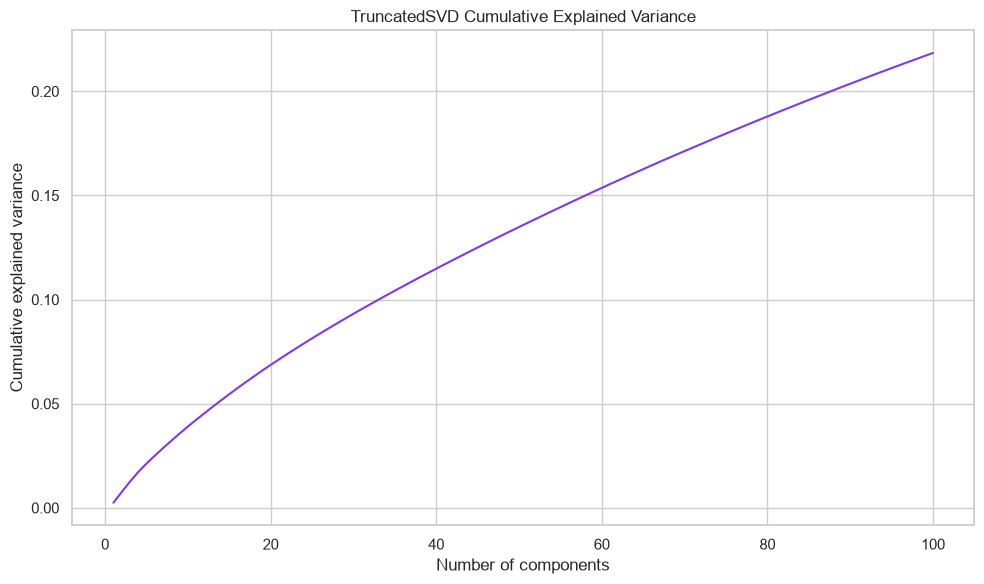

Original training TF-IDF shape: (1645, 3845)
Reduced training shape: (1645, 100)
Variance explained by 100 components: 0.2184


In [14]:
svd_tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    max_features=5000,
    sublinear_tf=True,
)
train_tfidf = svd_tfidf.fit_transform(X_train[text_feature])
svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
train_svd = svd.fit_transform(train_tfidf)
cum_variance = np.cumsum(svd.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(cum_variance) + 1), cum_variance, color="#7c3aed")
ax.set_title("TruncatedSVD Cumulative Explained Variance")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance")
fig.tight_layout()
fig.savefig(MODEL_FIG_DIR / "svd_explained_variance.png", dpi=300, bbox_inches="tight")
plt.show()

print("Original training TF-IDF shape:", train_tfidf.shape)
print("Reduced training shape:", train_svd.shape)
print("Variance explained by 100 components:", round(float(cum_variance[-1]), 4))

## 13. Hyperparameter tuning and model varieties

The search compares four regularization strengths, balanced versus unbalanced class weights, and unigram versus unigram-bigram TF-IDF. This produces 16 model varieties and 80 total fits under five-fold validation. Macro F1 is optimized due to class imbalance.

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid = {
    "preprocess__text__tfidf__ngram_range": [(1, 1), (1, 2)],
    "select__k": [1500],
    "model__C": [0.1, 0.5, 1.0, 2.0],
    "model__class_weight": [None, "balanced"],
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    refit=True,
)

grid_search.fit(X_train, y_train)
print("Candidates trained:", len(grid_search.cv_results_["params"]))
print("Best CV macro F1:", round(grid_search.best_score_, 4))
print("Best parameters:")
print(json.dumps(grid_search.best_params_, indent=2, default=str))

Fitting 5 folds for each of 16 candidates, totalling 80 fits


Candidates trained: 16
Best CV macro F1: 0.2623
Best parameters:
{
  "model__C": 0.1,
  "model__class_weight": "balanced",
  "preprocess__text__tfidf__ngram_range": [
    1,
    1
  ],
  "select__k": 1500
}


## 14. Compare model varieties

In [16]:
cv_results = pd.DataFrame(grid_search.cv_results_)
comparison_columns = [
    "param_model__C",
    "param_model__class_weight",
    "param_preprocess__text__tfidf__ngram_range",
    "param_select__k",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]
model_comparison = (
    cv_results[comparison_columns]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)
display(model_comparison.head(15))
model_comparison.to_csv(OUTPUT_DIR / "linear_svm_model_comparison.csv", index=False)

,param_model__C,param_model__class_weight,param_preprocess__text__tfidf__ngram_range,param_select__k,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,0.1,balanced,"(1, 1)",1500,0.857324,0.262340,0.023641,1
1,0.5,balanced,"(1, 1)",1500,0.963348,0.259526,0.032770,2
2,0.5,balanced,"(1, 2)",1500,0.947739,0.254437,0.024504,3
3,1.0,balanced,"(1, 1)",1500,0.981455,0.253011,0.027206,4
4,1.0,balanced,"(1, 2)",1500,0.970357,0.250804,0.022464,5
5,2.0,balanced,"(1, 2)",1500,0.984081,0.246737,0.029457,6
6,0.1,balanced,"(1, 2)",1500,0.838248,0.246237,0.018411,7
7,2.0,balanced,"(1, 1)",1500,0.990715,0.244865,0.026220,8
8,1.0,NaN,"(1, 1)",1500,0.979179,0.229579,0.026170,9
9,2.0,NaN,"(1, 1)",1500,0.992003,0.228499,0.022838,10


## 15. Final untouched-test evaluation

In [17]:
best_model = grid_search.best_estimator_
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

metrics = {
    "train_accuracy": accuracy_score(y_train, y_train_pred),
    "test_accuracy": accuracy_score(y_test, y_test_pred),
    "macro_precision": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
    "macro_recall": recall_score(y_test, y_test_pred, average="macro", zero_division=0),
    "macro_f1": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_test, y_test_pred, average="weighted", zero_division=0),
    "best_cv_macro_f1": grid_search.best_score_,
}

metrics_df = pd.DataFrame([metrics]).T.rename(columns={0: "score"})
display(metrics_df.round(4))
metrics_df.to_csv(OUTPUT_DIR / "linear_svm_metrics.csv")

report = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
display(report_df.round(4))
report_df.to_csv(OUTPUT_DIR / "linear_svm_classification_report.csv")

,score
train_accuracy,0.8091
test_accuracy,0.3641
macro_precision,0.2592
macro_recall,0.2512
macro_f1,0.2523
weighted_f1,0.3661
best_cv_macro_f1,0.2623


,precision,recall,f1-score,support
anger,0.1562,0.1923,0.1724,26.0000
anticipation,0.2593,0.2800,0.2692,50.0000
disgust,0.0345,0.0667,0.0455,15.0000
fear,0.1786,0.1667,0.1724,30.0000
joy,0.4000,0.3000,0.3429,80.0000
optimism,0.2571,0.1915,0.2195,47.0000
sadness,0.5287,0.5610,0.5444,164.0000
accuracy,0.3641,0.3641,0.3641,0.3641
macro avg,0.2592,0.2512,0.2523,412.0000
weighted avg,0.3731,0.3641,0.3661,412.0000


## 16. Confusion matrix

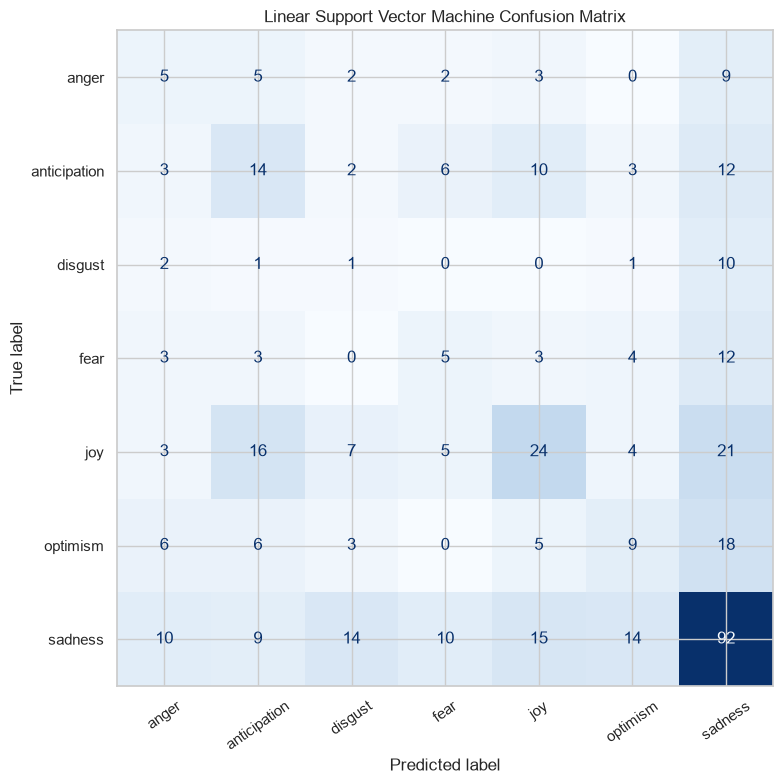

In [18]:
labels = sorted(y.unique())
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    labels=labels,
    display_labels=labels,
    cmap="Blues",
    xticks_rotation=35,
    ax=ax,
    colorbar=False,
)
ax.set_title("Linear Support Vector Machine Confusion Matrix")
fig.tight_layout()
fig.savefig(MODEL_FIG_DIR / "linear_svm_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 17. Five-fold cross-validation reliability

The tuned pipeline is evaluated using multiple metrics over the training data. Mean and standard deviation show expected generalization and stability.

In [19]:
scoring = {
    "accuracy": "accuracy",
    "macro_precision": "precision_macro",
    "macro_recall": "recall_macro",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
}
cv_scores = cross_validate(best_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
cv_summary = pd.DataFrame({
    metric.replace("test_", ""): {
        "mean": np.mean(values),
        "std": np.std(values),
    }
    for metric, values in cv_scores.items()
    if metric.startswith("test_")
}).T
display(cv_summary.round(4))
cv_summary.to_csv(OUTPUT_DIR / "linear_svm_cross_validation.csv")

,mean,std
accuracy,0.3781,0.0199
macro_precision,0.2681,0.0240
macro_recall,0.2606,0.0241
macro_f1,0.2623,0.0236
weighted_f1,0.3707,0.0206


## 18. Save predictions and trained model

In [20]:
predictions = pd.DataFrame({
    "actual_emotion": y_test.reset_index(drop=True),
    "predicted_emotion": pd.Series(y_test_pred),
})
predictions.to_csv(OUTPUT_DIR / "linear_svm_test_predictions.csv", index=False)
model_path = OUTPUT_DIR / "IT25100083_best_linear_svm.pkl"
with open(model_path, "wb") as model_file:
    cloudpickle.dump(best_model, model_file)

summary = {
    "student_id": "IT25100083",
    "student_name": "Unawatuna H. M. I. D.",
    "model": "Linear Support Vector Machine",
    "random_state": RANDOM_STATE,
    "best_parameters": grid_search.best_params_,
    "metrics": {key: float(value) for key, value in metrics.items()},
}
with open(OUTPUT_DIR / "linear_svm_summary.json", "w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2, default=str)

print("Saved model and outputs to:", OUTPUT_DIR)

Saved model and outputs to: /Users/lakshithadilshan/Documents/movie-emotion-recommendation-system/IT25100083/results/outputs


## 19. Conclusion, limitations, and improvements

**Model selection:** The final Linear Support Vector Machine variety is selected using five-fold cross-validated macro F1, not test-set performance. This protects the test set and gives equal importance to minority classes.

**Interpretation:** Compare macro F1 with weighted F1 and inspect the confusion matrix. A much lower macro F1 indicates weaker minority-class prediction. The `disgust` row deserves particular attention because it has the fewest training examples.

**Potential limitations:**

- Class imbalance, especially the small disgust class.
- Only 2,057 independent descriptions.
- Emotion labels may be subjective.
- Descriptions may contain incomplete summaries.
- Genre combinations encoded as categories can be sparse.
- The excluded surprise class cannot be predicted by the supervised model.

**Possible improvements:**

- Collect more independently labelled descriptions for minority emotions.
- Use multilabel genre encoding.
- Compare calibrated linear SVM and transformer embeddings.
- Conduct fairness/error analysis across genres.
- Add explainability using highest positive class coefficients.

## 20. Individual reflection

This implementation demonstrates that reliable evaluation depends on data quality, leakage-safe preprocessing, stratification, and metrics suited to imbalance. Linear Support Vector Machine is a strong interpretable baseline for high-dimensional TF-IDF text, but class-level analysis is essential before deployment.

## AI tool usage declaration

Generative AI assistance was used for code structuring, debugging suggestions, documentation organization, and explanation refinement. All code must be executed, checked, modified where necessary, and understood by the student before submission. The student remains responsible for every result and interpretation.